In [1]:
import os
os.chdir(r'C:\Projects\lmp-forecaster')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the raw data we saved in Phase 2
df = pd.read_csv(
    'data/raw/da_lmp_illinois_hub_2023_2024.csv',
    parse_dates=['Time']
)

# Set Time as index and sort
df = df.set_index('Time').sort_index()

# Keep only what we need
df = df[['LMP', 'Energy', 'Congestion', 'Loss']]

print("Shape:", df.shape)
print("Date range:", df.index.min(), "→", df.index.max())
print(df.head())

Shape: (17520, 4)
Date range: 2023-01-01 00:00:00-05:00 → 2024-12-30 23:00:00-05:00
                             LMP  Energy  Congestion  Loss
Time                                                      
2023-01-01 00:00:00-05:00  27.51   27.23        0.10  0.18
2023-01-01 01:00:00-05:00  26.48   26.15       -0.01  0.34
2023-01-01 02:00:00-05:00  26.36   25.64        0.00  0.72
2023-01-01 03:00:00-05:00  26.25   25.90        0.00  0.35
2023-01-01 04:00:00-05:00  25.59   25.06        0.00  0.53


In [2]:
# --- GROUP A: TEMPORAL FEATURES ---

# Basic time components
df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek   # 0=Monday, 6=Sunday
df['month']       = df.index.month
df['quarter']     = df.index.quarter

# Binary flags
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
df['is_monday']   = (df['day_of_week'] == 0).astype(int)  # Mondays are unique — low overnight, high morning ramp

# Season flags — based on what we saw in Phase 2
df['is_summer']   = df['month'].isin([6, 7, 8]).astype(int)
df['is_winter']   = df['month'].isin([12, 1, 2]).astype(int)

# Peak hour flag — hours 16-20 were most expensive in Chart 2
df['is_peak_hour']    = df['hour'].isin(range(16, 21)).astype(int)
df['is_offpeak_hour'] = df['hour'].isin(range(0, 6)).astype(int)

print("Temporal features added:", ['hour','day_of_week','month','quarter',
      'is_weekend','is_monday','is_summer','is_winter',
      'is_peak_hour','is_offpeak_hour'])

Temporal features added: ['hour', 'day_of_week', 'month', 'quarter', 'is_weekend', 'is_monday', 'is_summer', 'is_winter', 'is_peak_hour', 'is_offpeak_hour']


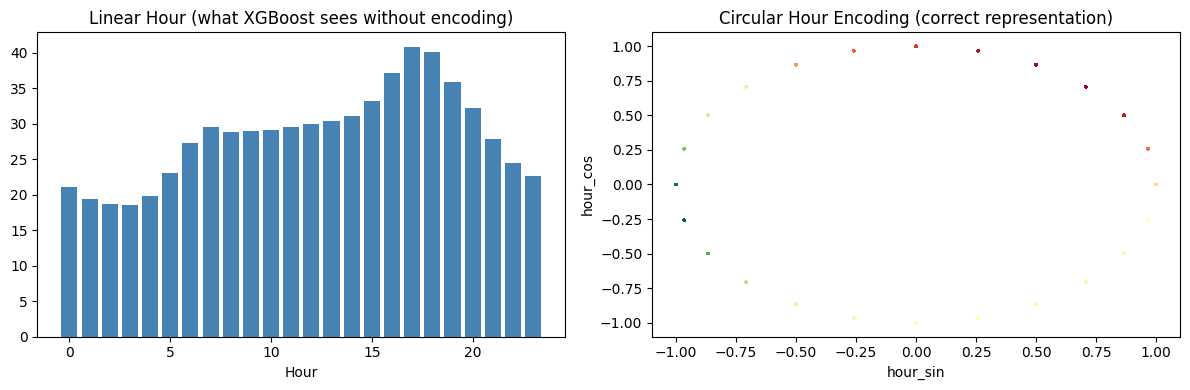

Hour encoding features added: hour_sin, hour_cos, dow_sin, dow_cos, month_sin, month_cos


In [3]:
# Plain hour treats time as linear — but it's circular
# Hour 23 and Hour 0 are only 1 hour apart in reality
# but numerically they're 23 apart — XGBoost sees them as far away

# Fix: sine/cosine encoding makes the circle continuous
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['dow_sin']  = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']  = np.cos(2 * np.pi * df['day_of_week'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Visualize why this matters
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(24), df.groupby('hour')['LMP'].mean(), color='steelblue')
axes[0].set_title('Linear Hour (what XGBoost sees without encoding)')
axes[0].set_xlabel('Hour')

axes[1].scatter(df['hour_sin'], df['hour_cos'], 
                c=df.groupby(df.index.hour)['LMP'].transform('mean'),
                cmap='RdYlGn', s=1)
axes[1].set_title('Circular Hour Encoding (correct representation)')
axes[1].set_xlabel('hour_sin')
axes[1].set_ylabel('hour_cos')

plt.tight_layout()
plt.savefig('results/hour_encoding.png', dpi=150)
plt.show()

print("Hour encoding features added: hour_sin, hour_cos, dow_sin, dow_cos, month_sin, month_cos")

In [4]:
# --- GROUP B: LAGGED LMP FEATURES ---
# Remember: minimum lag = 24h (yesterday) to avoid leakage

# Same hour yesterday, 2 days ago, last week
df['lmp_lag_24h']  = df['LMP'].shift(24)
df['lmp_lag_48h']  = df['LMP'].shift(48)
df['lmp_lag_72h']  = df['LMP'].shift(72)
df['lmp_lag_168h'] = df['LMP'].shift(168)   # Same hour last week

# Lagged components — congestion yesterday was predictive of today
df['congestion_lag_24h']  = df['Congestion'].shift(24)
df['congestion_lag_168h'] = df['Congestion'].shift(168)

# Was there a price spike yesterday?
spike_threshold = df['LMP'].mean() + 2 * df['LMP'].std()
df['spike_lag_24h'] = (df['lmp_lag_24h'] > spike_threshold).astype(int)

print(f"Spike threshold: ${spike_threshold:.2f}/MWh")
print("Lag features added")
df[['LMP', 'lmp_lag_24h', 'lmp_lag_168h', 'congestion_lag_24h']].head(30).tail(10)

Spike threshold: $57.89/MWh
Lag features added


,LMP,lmp_lag_24h,lmp_lag_168h,congestion_lag_24h
Time,,,,
2023-01-01 20:00:00-05:00,38.55,NaN,NaN,NaN
2023-01-01 21:00:00-05:00,37.31,NaN,NaN,NaN
2023-01-01 22:00:00-05:00,34.73,NaN,NaN,NaN
2023-01-01 23:00:00-05:00,33.47,NaN,NaN,NaN
2023-01-02 00:00:00-05:00,27.42,27.51,NaN,0.10
2023-01-02 01:00:00-05:00,27.05,26.48,NaN,-0.01
2023-01-02 02:00:00-05:00,25.21,26.36,NaN,0.00
2023-01-02 03:00:00-05:00,26.54,26.25,NaN,0.00
2023-01-02 04:00:00-05:00,26.63,25.59,NaN,0.00


Why these specific lags? 
| Lag | Captures|
|-----|---------|
|24h|Yesterday same hour — strongest single predictor|
|48h|Two days ago — smooths out one-day anomalies|
|72h|Three days ago — early week pattern|
|168h| Last week same hour — weekly seasonality|

In [5]:
# --- GROUP C: ROLLING STATISTICS ---
# All rolled on LAGGED data (shift first, then roll)
# These tell model whether the recent market has been calm or volatitle. 

lmp_lagged = df['LMP'].shift(24)

# Rolling averages — recent price level
df['lmp_roll_24h_mean']  = lmp_lagged.rolling(24).mean()
df['lmp_roll_48h_mean']  = lmp_lagged.rolling(48).mean()
df['lmp_roll_7d_mean']   = lmp_lagged.rolling(168).mean()

# Rolling std — recent market volatility
df['lmp_roll_24h_std']   = lmp_lagged.rolling(24).std()
df['lmp_roll_7d_std']    = lmp_lagged.rolling(168).std()

# Rolling min/max — price range context
df['lmp_roll_24h_max']   = lmp_lagged.rolling(24).max()
df['lmp_roll_24h_min']   = lmp_lagged.rolling(24).min()

# Price relative to recent average — is today likely above/below normal?
df['lmp_vs_7d_avg'] = df['lmp_lag_24h'] / df['lmp_roll_7d_mean']

print("Rolling features added")
print("\nSample — notice NaN at the start (not enough history yet):")
df[['LMP', 'lmp_roll_24h_mean', 'lmp_roll_24h_std', 'lmp_vs_7d_avg']].head(30).tail(10)

Rolling features added

Sample — notice NaN at the start (not enough history yet):


,LMP,lmp_roll_24h_mean,lmp_roll_24h_std,lmp_vs_7d_avg
Time,,,,
2023-01-01 20:00:00-05:00,38.55,NaN,NaN,NaN
2023-01-01 21:00:00-05:00,37.31,NaN,NaN,NaN
2023-01-01 22:00:00-05:00,34.73,NaN,NaN,NaN
2023-01-01 23:00:00-05:00,33.47,NaN,NaN,NaN
2023-01-02 00:00:00-05:00,27.42,NaN,NaN,NaN
2023-01-02 01:00:00-05:00,27.05,NaN,NaN,NaN
2023-01-02 02:00:00-05:00,25.21,NaN,NaN,NaN
2023-01-02 03:00:00-05:00,26.54,NaN,NaN,NaN
2023-01-02 04:00:00-05:00,26.63,NaN,NaN,NaN


Notice the NaN values at the start — that's expected. The first 168 rows won't have a full week of history. We'll handle this when we clean the feature matrix.

In [7]:
# --- GROUP D: HOLIDAY FEATURES ---
import holidays

us_holidays = holidays.US(years=[2023, 2024])

# Strip timezone before comparing dates
dates_no_tz = df.index.tz_localize(None).normalize()

df['is_holiday'] = dates_no_tz.isin(us_holidays).astype(int)

df['is_day_before_holiday'] = dates_no_tz.isin(
    [d - pd.Timedelta(days=1) for d in us_holidays.keys()]
).astype(int)

print(f"Holiday hours: {df['is_holiday'].sum()}")
print(f"Day-before-holiday hours: {df['is_day_before_holiday'].sum()}")
print(f"\nAverage LMP on holidays: ${df[df['is_holiday']==1]['LMP'].mean():.2f}/MWh")
print(f"Average LMP on normal days: ${df[df['is_holiday']==0]['LMP'].mean():.2f}/MWh")

Holiday hours: 576
Day-before-holiday hours: 552

Average LMP on holidays: $32.54/MWh
Average LMP on normal days: $28.16/MWh


In [8]:
# --- The final save cell ---
# Drop rows with NaN (first ~168 rows missing rolling history)
df_features = df.dropna()

print(f"Original rows: {len(df):,}")
print(f"After dropping NaN: {len(df_features):,}")
print(f"Rows dropped: {len(df) - len(df_features):,}")
print(f"\nTotal features built: {len(df_features.columns)}")
print("\nAll columns:")
for col in df_features.columns:
    print(f"  {col}")

# Save
df_features.to_csv('data/features/feature_matrix_v1.csv')
print("\nSaved to data/features/feature_matrix_v1.csv")

Original rows: 17,520
After dropping NaN: 17,329
Rows dropped: 191

Total features built: 37

All columns:
  LMP
  Energy
  Congestion
  Loss
  hour
  day_of_week
  month
  quarter
  is_weekend
  is_monday
  is_summer
  is_winter
  is_peak_hour
  is_offpeak_hour
  hour_sin
  hour_cos
  dow_sin
  dow_cos
  month_sin
  month_cos
  lmp_lag_24h
  lmp_lag_48h
  lmp_lag_72h
  lmp_lag_168h
  congestion_lag_24h
  congestion_lag_168h
  spike_lag_24h
  lmp_roll_24h_mean
  lmp_roll_48h_mean
  lmp_roll_7d_mean
  lmp_roll_24h_std
  lmp_roll_7d_std
  lmp_roll_24h_max
  lmp_roll_24h_min
  lmp_vs_7d_avg
  is_holiday
  is_day_before_holiday

Saved to data/features/feature_matrix_v1.csv


What we just built
37 columns total:
- 1 target variable (`LMP`)
- 3 component columns (`Energy`, `Congestion`, `Loss`) — used as lag features later
- 33 features the model will actually learn from
191 rows dropped — that's exactly 7 days + a few hours of warmup needed for the 168h rolling window.

Feature matrix at a Glance:
|Group | Features | Count|
|------|----------|------|
|Target|`LMP` |1 |
|Components| `Energy`, `Congestion`, `Loss` | 3|
|Temporal (raw)| `hour`, `day_of_week`, `month`, `quarter`| 4|
|Temporal (flags)| `is_weekend`, `is_monday`, `is_summer`, `is_winter`, `is_peak_hour`, `is_offpeak_hour`|6|
|Temporal (circular)|`hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`, `month_sin`, `month_cos`|6|
|Lagged LMP|`lmp_lag_24h`, `lmp_lag_48h`, `lmp_lag_72h`, `lmp_lag_168h`|4|
|Lagged Congestion| `congestion_lag_24h`, `congestion_lag_168h` |2|
|Spike flag| `spike_lag_24h`|1|
|Rolling stats|`lmp_roll_24h_mean`, `lmp_roll_48h_mean`, `lmp_roll_7d_mean`, `lmp_roll_24h_std`, `lmp_roll_7d_std`, `lmp_roll_24h_max`, `lmp_roll_24h_min`, `lmp_vs_7d_avg` |8|
|Holidays | `is_holiday`, `is_day_before_holiday` |2|